# Day 5 — Correlation vs. Causation
### 30 Days of Machine Learning | For Data Analysts & Data Scientists

Companion notebook to the Day 5 carousel. Every cell is executed — every chart and number matches what's on the slides.

**The 5 traps covered:**
1. Confounding variable — ice cream sales & drownings, both driven by temperature
2. Reverse causation — practice hours vs. confidence score
3. Spurious correlation — margarine consumption vs. data-science job postings
4. Selection bias — satisfaction score vs. tenure, with churned customers missing
5. Simpson's paradox — code review hours vs. bugs shipped, junior vs. senior devs

All data below is **simulated** with fixed seeds for reproducibility — built to demonstrate each trap cleanly, not pulled from a real company.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 4)

# Palette matching the carousel (Coral Energy)
NAVY = "#2F3C7E"
CORAL = "#F96167"
GOLD = "#F4A300"
GREEN = "#1F9D6B"
INK = "#1C2140"

print("Setup complete.")


Setup complete.


## Trap 1 — Confounding Variable

Two variables move together only because something else is moving them both. Here, **temperature** independently drives both ice-cream sales and drowning incidents — neither causes the other.


In [2]:
np.random.seed(42)
n = 120

temperature = np.random.uniform(15, 38, n)
ice_cream_sales = 20 + 2.2 * temperature + np.random.normal(0, 9, n)
drowning_incidents = -2 + 0.55 * temperature + np.random.normal(0, 2.2, n)

r_confound, p_confound = stats.pearsonr(ice_cream_sales, drowning_incidents)
print(f"r(ice cream, drownings) = {r_confound:.2f}, p = {p_confound:.2e}")
print(f"r(ice cream, temperature) = {stats.pearsonr(ice_cream_sales, temperature)[0]:.2f}")
print(f"r(drownings, temperature) = {stats.pearsonr(drowning_incidents, temperature)[0]:.2f}")


r(ice cream, drownings) = 0.74, p = 4.89e-22
r(ice cream, temperature) = 0.85
r(drownings, temperature) = 0.84


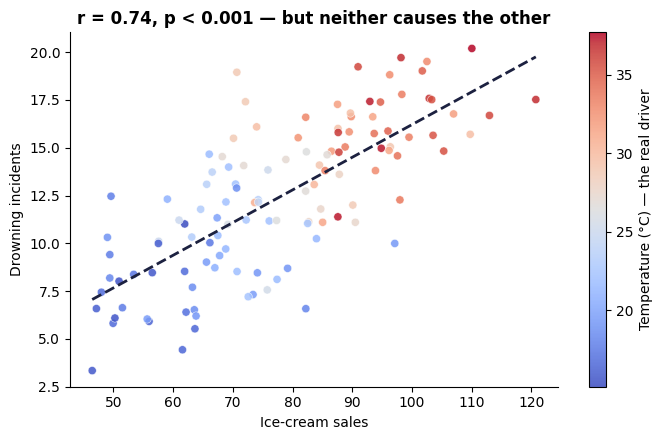

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sc = ax.scatter(ice_cream_sales, drowning_incidents, c=temperature, cmap="coolwarm",
                 s=35, alpha=0.85, edgecolor="white", linewidth=0.4)
slope, intercept = np.polyfit(ice_cream_sales, drowning_incidents, 1)
xs = np.linspace(ice_cream_sales.min(), ice_cream_sales.max(), 100)
ax.plot(xs, slope * xs + intercept, "--", color=INK, linewidth=2)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Temperature (°C) — the real driver")
ax.set_xlabel("Ice-cream sales")
ax.set_ylabel("Drowning incidents")
ax.set_title(f"r = {r_confound:.2f}, p < 0.001 — but neither causes the other", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("trap1_confounder.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** ice-cream sales and drownings rise together every summer. Neither causes the other — hot weather drives both ice-cream buying and swimming. **Watch for:** any correlation between two effects of the same upstream cause.

## Trap 2 — Reverse Causation

The arrow you assumed may be pointing backward. "People who practice more report higher confidence" fits a story where practice builds confidence — and just as well fits one where confident people practice more.


In [4]:
np.random.seed(14)
weeks = np.arange(1, 27)
practice_hours = 2 + 0.38 * weeks + np.random.normal(0, 1.4, len(weeks))
confidence_score = 38 + 1.25 * weeks + np.random.normal(0, 4.5, len(weeks))

r_reverse, p_reverse = stats.pearsonr(practice_hours, confidence_score)
print(f"r(practice hours, confidence) = {r_reverse:.2f}, p = {p_reverse:.2e}")
print("Story A: practice -> confidence")
print("Story B: confidence -> practice")
print("The correlation alone cannot distinguish between them.")


r(practice hours, confidence) = 0.82, p = 2.60e-07
Story A: practice -> confidence
Story B: confidence -> practice
The correlation alone cannot distinguish between them.


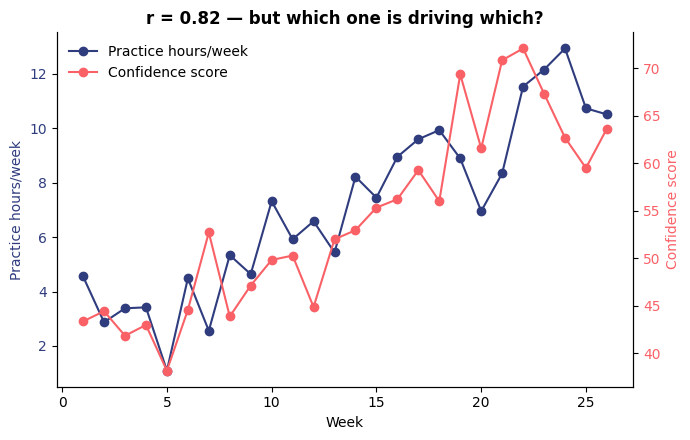

In [5]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(weeks, practice_hours, "o-", color=NAVY, label="Practice hours/week")
ax1.set_xlabel("Week")
ax1.set_ylabel("Practice hours/week", color=NAVY)
ax1.tick_params(axis="y", labelcolor=NAVY)

ax2 = ax1.twinx()
ax2.plot(weeks, confidence_score, "o-", color=CORAL, label="Confidence score")
ax2.set_ylabel("Confidence score", color=CORAL)
ax2.tick_params(axis="y", labelcolor=CORAL)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)
ax1.set_title(f"r = {r_reverse:.2f} — but which one is driving which?", fontsize=12, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
plt.tight_layout()
plt.savefig("trap2_reverse_causation.png", dpi=150, bbox_inches="tight")
plt.show()


**Watch for:** any "X leads to Y" claim built on a snapshot, not a timeline. Without knowing which moved first, the direction of the arrow is a guess.

## Trap 3 — Spurious Correlation

Anything that grows steadily over time will correlate with anything else that does too — margarine consumption and data-science job postings have nothing to do with each other.


In [6]:
np.random.seed(0)
years = np.arange(2004, 2024)
margarine_kg_capita = 3.5 + 0.35 * (years - 2004) + np.random.normal(0, 0.5, len(years))
ds_job_postings = 750 + 50 * (years - 2004) + np.random.normal(0, 60, len(years))

r_spurious, p_spurious = stats.pearsonr(margarine_kg_capita, ds_job_postings)
print(f"r(margarine, DS job postings) = {r_spurious:.3f}, p = {p_spurious:.2e}")


r(margarine, DS job postings) = 0.957, p = 3.84e-11


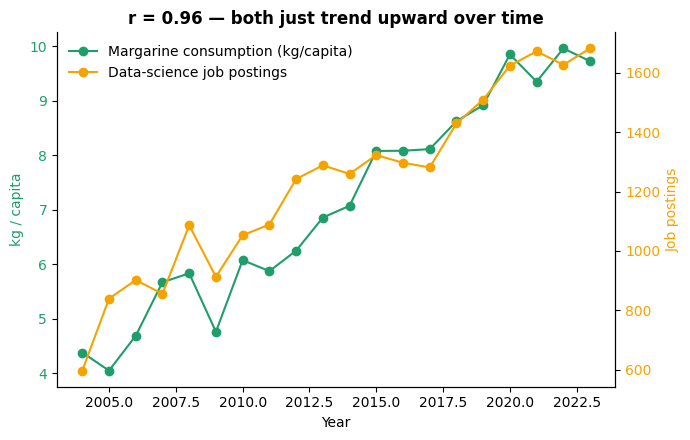

In [7]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(years, margarine_kg_capita, "o-", color=GREEN, label="Margarine consumption (kg/capita)")
ax1.set_xlabel("Year")
ax1.set_ylabel("kg / capita", color=GREEN)
ax1.tick_params(axis="y", labelcolor=GREEN)

ax2 = ax1.twinx()
ax2.plot(years, ds_job_postings, "o-", color=GOLD, label="Data-science job postings")
ax2.set_ylabel("Job postings", color=GOLD)
ax2.tick_params(axis="y", labelcolor=GOLD)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)
ax1.set_title(f"r = {r_spurious:.2f} — both just trend upward over time", fontsize=12, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
plt.tight_layout()
plt.savefig("trap3_spurious.png", dpi=150, bbox_inches="tight")
plt.show()


**Watch for:** high correlation between two time series with no plausible link. If both series just trend with time, population, or inflation, they'll correlate regardless of content.

## Trap 4 — Selection Bias

If the data-generating process filters who shows up, the correlation you see is filtered too. Surveying only *current* users to learn "what makes people stay" hides everyone who already churned.


In [8]:
np.random.seed(42)
n = 3000

months_as_customer = np.clip(np.random.exponential(scale=25, size=n), 0, 110)
satisfaction_score = 70 - 0.9 * months_as_customer + np.random.normal(0, 12, n)

# Lower satisfaction -> higher churn probability
churn_prob = 1 / (1 + np.exp((satisfaction_score - 30) / 8))
churned = np.random.binomial(1, churn_prob)
active = churned == 0

print(f"Total customers simulated: {n}")
print(f"Still active (what a 'current users' survey would see): {active.sum()}")
print(f"Churned (missing from that survey): {churned.sum()}")
print(f"Correlation using EVERYONE: {stats.pearsonr(months_as_customer, satisfaction_score)[0]:.2f}")
print(f"Correlation using ACTIVE USERS ONLY: {stats.pearsonr(months_as_customer[active], satisfaction_score[active])[0]:.2f}")


Total customers simulated: 3000
Still active (what a 'current users' survey would see): 2328
Churned (missing from that survey): 672
Correlation using EVERYONE: -0.87
Correlation using ACTIVE USERS ONLY: -0.67


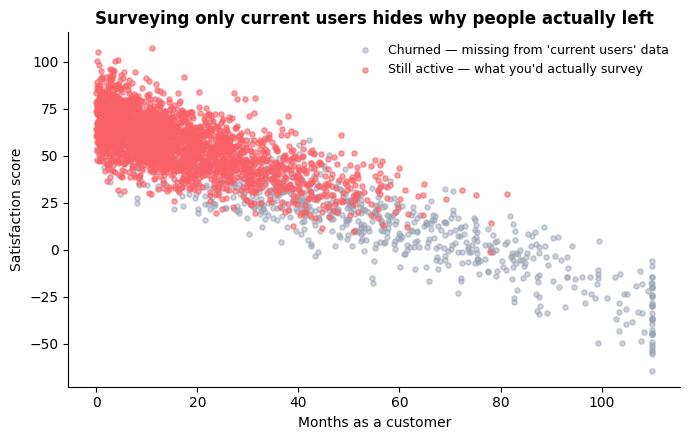

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(months_as_customer[~active], satisfaction_score[~active], s=14, alpha=0.5,
           color="#9AA3B2", label="Churned — missing from 'current users' data")
ax.scatter(months_as_customer[active], satisfaction_score[active], s=14, alpha=0.6,
           color=CORAL, label="Still active — what you'd actually survey")
ax.set_xlabel("Months as a customer")
ax.set_ylabel("Satisfaction score")
ax.set_title("Surveying only current users hides why people actually left", fontsize=12, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("trap4_selection_bias.png", dpi=150, bbox_inches="tight")
plt.show()


**Watch for:** any "users" analysis that silently drops the people who left. The missing group is often exactly the one that would explain the pattern.

## Trap 5 — Simpson's Paradox

A relationship can run one way overall and the opposite way inside every subgroup. Pooled, more code review looks linked to MORE bugs. Split by seniority, more review reduces bugs in both groups.


In [10]:
np.random.seed(42)
n = 80

junior_review_hrs = np.random.uniform(1, 5, n)
junior_bugs = 9 - 0.9 * junior_review_hrs + np.random.normal(0, 0.6, n)

senior_review_hrs = np.random.uniform(4, 9, n)
senior_bugs = 13 - 0.7 * senior_review_hrs + np.random.normal(0, 0.6, n)

combined_review = np.concatenate([junior_review_hrs, senior_review_hrs])
combined_bugs = np.concatenate([junior_bugs, senior_bugs])

junior_slope = np.polyfit(junior_review_hrs, junior_bugs, 1)[0]
senior_slope = np.polyfit(senior_review_hrs, senior_bugs, 1)[0]
combined_slope = np.polyfit(combined_review, combined_bugs, 1)[0]

print(f"Junior devs:   slope = {junior_slope:+.2f}  (more review -> fewer bugs)")
print(f"Senior devs:   slope = {senior_slope:+.2f}  (more review -> fewer bugs)")
print(f"Combined:      slope = {combined_slope:+.2f}  (more review -> MORE bugs — reversed!)")


Junior devs:   slope = -0.83  (more review -> fewer bugs)
Senior devs:   slope = -0.70  (more review -> fewer bugs)
Combined:      slope = +0.08  (more review -> MORE bugs — reversed!)


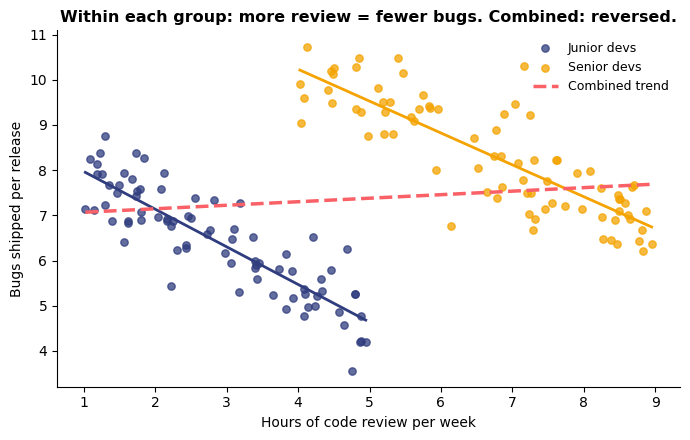

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(junior_review_hrs, junior_bugs, s=28, color=NAVY, alpha=0.75, label="Junior devs")
ax.scatter(senior_review_hrs, senior_bugs, s=28, color=GOLD, alpha=0.75, label="Senior devs")

xj = np.linspace(junior_review_hrs.min(), junior_review_hrs.max(), 50)
ax.plot(xj, np.polyval(np.polyfit(junior_review_hrs, junior_bugs, 1), xj), color=NAVY, linewidth=2)
xs_ = np.linspace(senior_review_hrs.min(), senior_review_hrs.max(), 50)
ax.plot(xs_, np.polyval(np.polyfit(senior_review_hrs, senior_bugs, 1), xs_), color=GOLD, linewidth=2)

xc = np.linspace(combined_review.min(), combined_review.max(), 50)
ax.plot(xc, np.polyval(np.polyfit(combined_review, combined_bugs, 1), xc), "--", color=CORAL, linewidth=2.5, label="Combined trend")

ax.set_xlabel("Hours of code review per week")
ax.set_ylabel("Bugs shipped per release")
ax.set_title("Within each group: more review = fewer bugs. Combined: reversed.", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("trap5_simpsons_paradox.png", dpi=150, bbox_inches="tight")
plt.show()


**Watch for:** an aggregate trend you haven't checked within each subgroup. Seniors simply review more AND ship harder, riskier features — seniority is the hidden variable Simpson's paradox is hiding.

## All Five, Side by Side


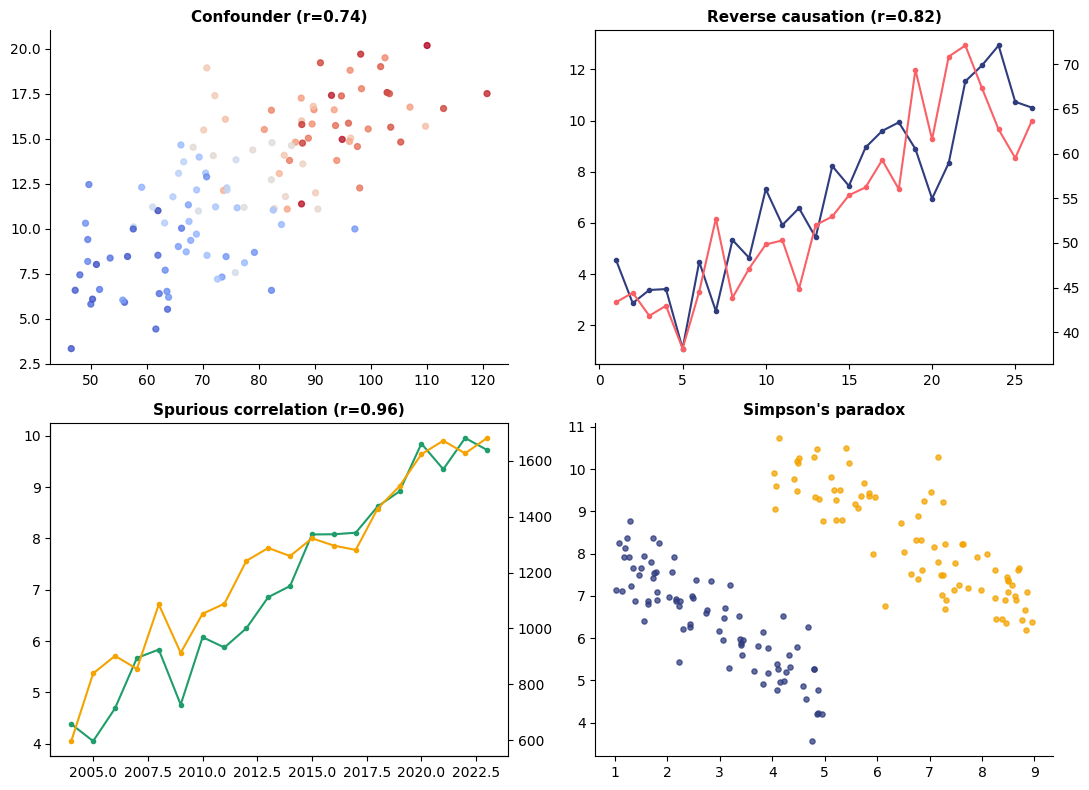

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sc = axes[0, 0].scatter(ice_cream_sales, drowning_incidents, c=temperature, cmap="coolwarm", s=18, alpha=0.8)
axes[0, 0].set_title("Confounder (r=0.74)", fontweight="bold", fontsize=11)

axes[0, 1].plot(weeks, practice_hours, "o-", color=NAVY, markersize=3)
ax2b = axes[0, 1].twinx()
ax2b.plot(weeks, confidence_score, "o-", color=CORAL, markersize=3)
axes[0, 1].set_title("Reverse causation (r=0.82)", fontweight="bold", fontsize=11)

axes[1, 0].plot(years, margarine_kg_capita, "o-", color=GREEN, markersize=3)
ax4b = axes[1, 0].twinx()
ax4b.plot(years, ds_job_postings, "o-", color=GOLD, markersize=3)
axes[1, 0].set_title("Spurious correlation (r=0.96)", fontweight="bold", fontsize=11)

axes[1, 1].scatter(junior_review_hrs, junior_bugs, s=14, color=NAVY, alpha=0.75)
axes[1, 1].scatter(senior_review_hrs, senior_bugs, s=14, color=GOLD, alpha=0.75)
axes[1, 1].set_title("Simpson's paradox", fontweight="bold", fontsize=11)

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("all_five_traps_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## Cheat Sheet

| Trap | What's happening | Watch for |
|---|---|---|
| Confounder | A third factor drives both variables | Two things that both correlate with "season," "size," or "time" |
| Reverse causation | Y may be causing X, not X causing Y | "X leads to Y" claims based on a single snapshot, not a timeline |
| Spurious correlation | Both series just trend with time or size | Suspiciously clean r between two unrelated-sounding time series |
| Selection bias | The sample quietly filtered out the answer | Any "current users" or "survivors" analysis |
| Simpson's paradox | The trend flips once you split into groups | An aggregate trend you haven't checked within subgroups |

## Stress-Test Any Causal Claim In 3 Steps
1. **Name the mechanism** — state out loud exactly how X would physically or behaviorally cause Y.
2. **Look for a third variable** — list anything else that could move both X and Y at the same time.
3. **Check subgroups and timing** — split the data by an obvious group, and confirm X moved before Y did.

If the story still holds after all three checks, you might actually have causation — or you need an experiment to be sure.
